# Daily vs Multi-Frequency LSTM Ablation Study

An ablation study asks whether a specific ingredient actually helps. Here the ingredient is multi-frequency yield-change features.

We compare two otherwise matched LSTMs:

- **Daily model**: yield levels + 1-day changes
- **Multi-frequency model**: yield levels + 1-day + 5-day + 21-day changes

The target, split logic, hidden size, optimizer, learning rate, early stopping, and seed are kept the same as much as practical.

## Why this matters

More features do not automatically mean a better model. Extra features can help if they add useful signal, but they can also add noise. The ablation tells us whether the multi-frequency features helped in this run.

In [1]:
# ruff: noqa: E402, I001
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_PATH = PROJECT_ROOT / "reports" / "tables" / "ablation_results.csv"
SUMMARY_PATH = PROJECT_ROOT / "results" / "ablation_summary.json"
RMSE_FIGURE = PROJECT_ROOT / "reports" / "figures" / "ablation_rmse_by_maturity.png"
LOSS_FIGURE = PROJECT_ROOT / "reports" / "figures" / "ablation_validation_loss.png"

## Load saved results

This notebook reads the saved ablation outputs. It does not retrain the models.

In [2]:
metrics = pd.read_csv(RESULTS_PATH)
summary = json.loads(SUMMARY_PATH.read_text())
summary["hypothesis"], summary["conclusion"]

('Adding 5-day and 21-day yield-change features improves LSTM forecast performance over daily-only features.',
 'not supported')

## Overall test comparison

The main comparison uses the overall test-set MAE and RMSE in basis points. Lower is better.

In [3]:
overall_test = metrics[
    (metrics["split"] == "test") & (metrics["maturity"] == "overall")
].copy()
overall_test[["feature_set", "model", "mae_bp", "rmse_bp"]].sort_values("rmse_bp")

,feature_set,model,mae_bp,rmse_bp
32,daily_lstm,persistence_zero_change,3.675,5.453
80,multi_frequency_lstm,persistence_zero_change,3.679,5.457
8,daily_lstm,daily_lstm,3.756,5.502
56,multi_frequency_lstm,multi_frequency_lstm,3.805,5.544
40,daily_lstm,linear_regression,3.946,5.643
88,multi_frequency_lstm,linear_regression,3.994,5.679


## Error by maturity

The figure below compares test RMSE across maturities. This shows whether one model wins everywhere or only on certain parts of the curve.

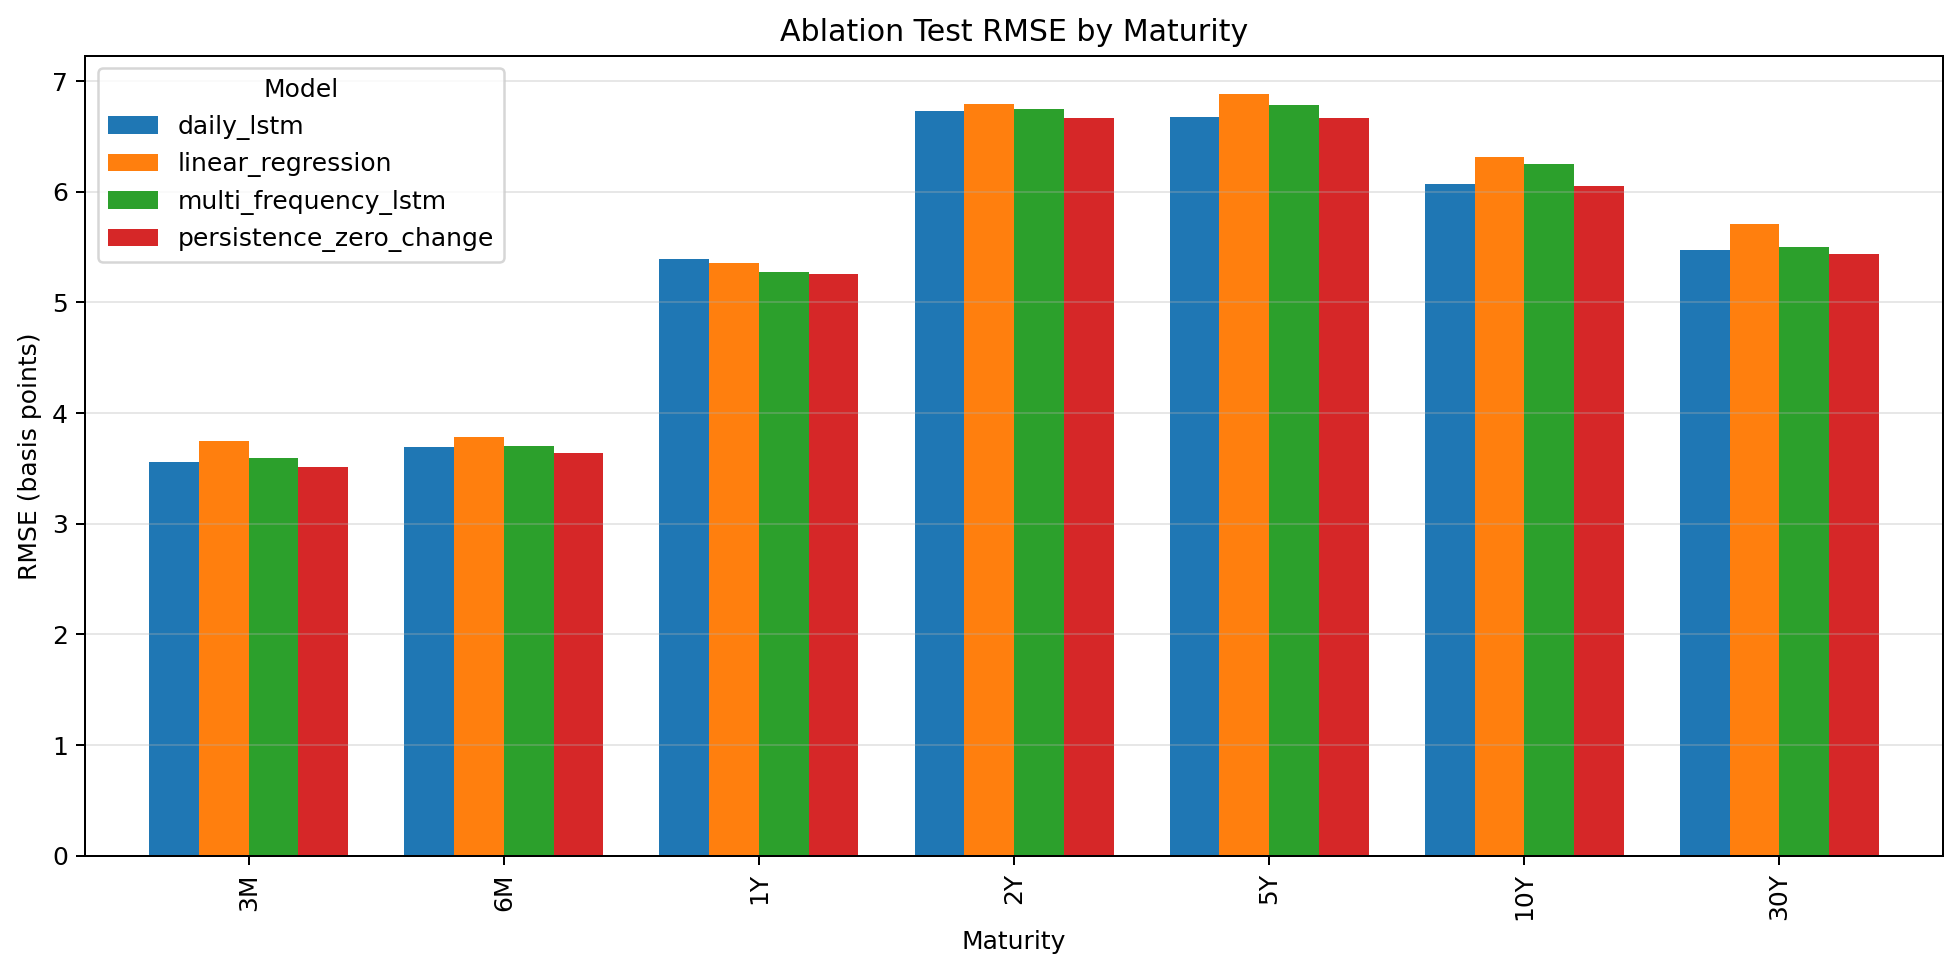

In [4]:
display(Image(filename=RMSE_FIGURE))

## Validation loss during training

The validation-loss curves show the early-stopping behavior. These losses are MSE values in the model's target units, not basis points.

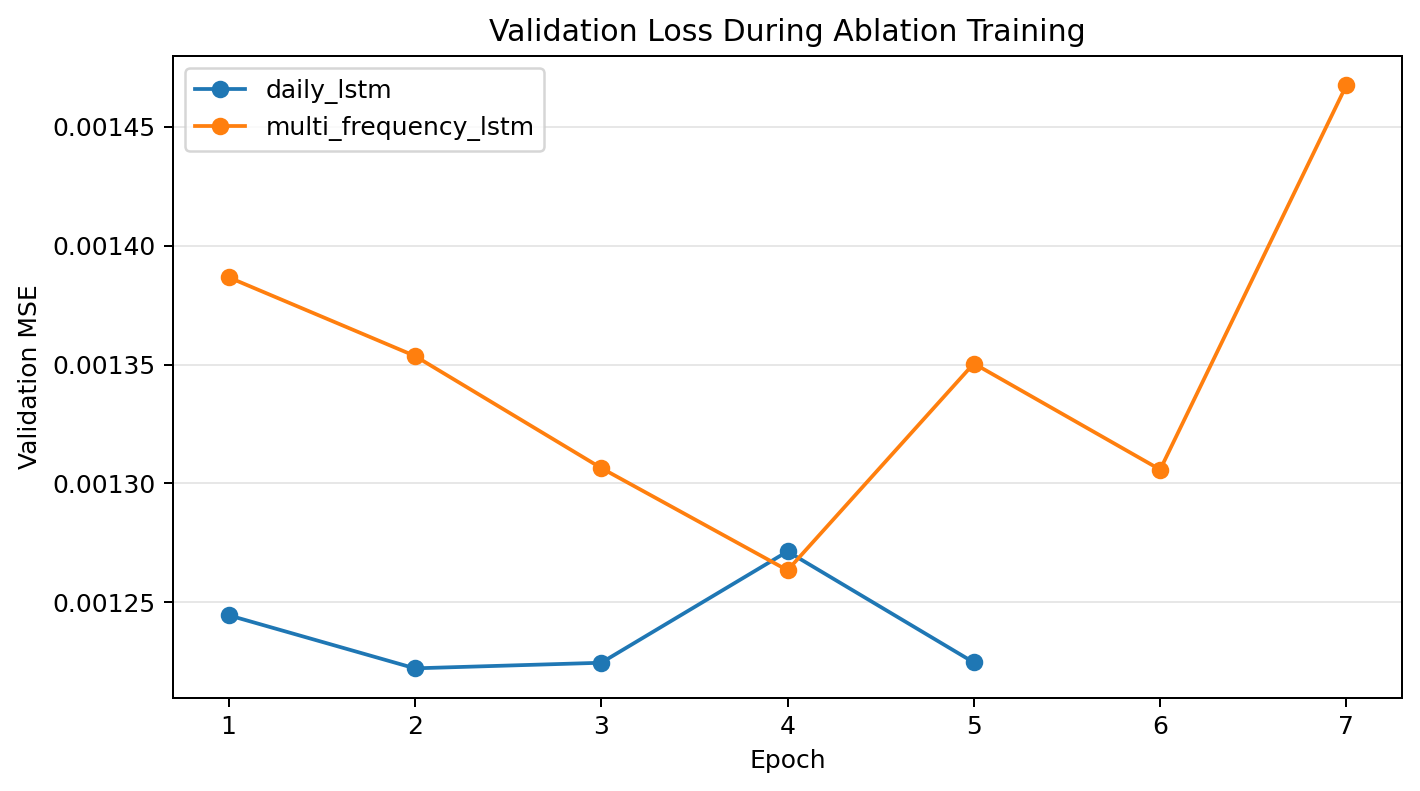

In [5]:
display(Image(filename=LOSS_FIGURE))

## Performance relative to baselines

A neural model should be compared against simple alternatives. Here we compare both LSTM variants against persistence and linear regression.

In [6]:
baseline_view = overall_test.pivot_table(
    index="model",
    values=["mae_bp", "rmse_bp"],
    aggfunc="first",
).sort_values("rmse_bp")
baseline_view

,mae_bp,rmse_bp
model,,
persistence_zero_change,3.675,5.453
daily_lstm,3.756,5.502
multi_frequency_lstm,3.805,5.544
linear_regression,3.946,5.643


## Conclusion

The hypothesis was **not supported** in this run. The daily-only LSTM slightly outperformed the multi-frequency LSTM on overall test MAE and RMSE. Neither LSTM beat the persistence baseline.

That does not prove multi-frequency features can never help. It only says that under this matched setup, with these features and this small LSTM, the extra 5-day and 21-day change features did not improve the result.